# Getting Data

First, we want to grab some graphs and subject covariates from a web-accessible url.  We've given this to you on github rather than having you set up aws s3 credentials or asking you to mount data in colab, in the interest of saving time. The original data is hosted at m2g.io

Below, you will be getting the following dataset:

| Property | Value |
|:--------:|:-----:|
| Dataset  | SWU4  |
| N-Subjects  | 454   |
| Scans-per-subjects | 2 |
| Atlases | Desikan, CPAC200 |
| Desikan Nodes | 70 |
| CPAC200 Nodes | 200 |

The covariates you have are: `SUBID, SESSION, AGE_AT_SCAN_1, SEX, RESTING_STATE_INSTRUCTION, TIME_OF_DAY, SEASON, SATIETY, LMP`. There are other columns in the `.csv` file (downloaded in the next step) but they are populated with a `#` meaning that the value was not recorded.

There are several other atlases available - you can change which one you use
Running the cell below will get you the data. **Please note, you only have to run these two cells once!!!**

## Loading Graphs + Covariates
Run the following cells of code to load the graphs into your computer, as well as the covariates.

In [1]:
#!pip install networkx

import numpy as np
import networkx as nx
import scipy as sp
import matplotlib.pyplot as plt
import os
import csv
from collections import OrderedDict
import glob

In [2]:
# get code and data
!git clone https://github.com/wrgr/graph-explorer.git

Cloning into 'graph-explorer'...
remote: Enumerating objects: 1150, done.
remote: Counting objects: 100% (1150/1150), done.
remote: Compressing objects: 100% (1145/1145), done.
remote: Total 1150 (delta 11), reused 1131 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (1150/1150), 15.57 MiB | 20.84 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [6]:
# set paths
ps = "graph-explorer/SWU4-matched.csv"

# Initializing dataset names
dataset_names = 'swu-data'
basepath = 'graph-explorer'

atlas = 'desikan' # only desikan for now - but can extend to other atlases

In [7]:

dir_names = basepath + '/' + dataset_names + '/' + atlas
print(dir_names)
fs = sorted(glob.glob(dir_names + '/*.csv'))

print("Total Subjects: %d" % len(fs))



graph-explorer/swu-data/desikan
Total Subjects: 207


In [8]:
# load graphs - note that this process requires alignment of labels and graphs by file name, so is brittle for general practice.
graphs = OrderedDict()
i = 0
for f in fs:
  graphs[i] = nx.read_weighted_edgelist(f)
  i = i+1

In [14]:
import pandas as pd
import csv

# This gets age and sex, respecitvely.
attributes = pd.read_csv(ps)

depvar = attributes['SEX']

## ASSIGNMENT:  
(Code above used to get data in the correct format.  Below is a simple example test string with kind of silly features)

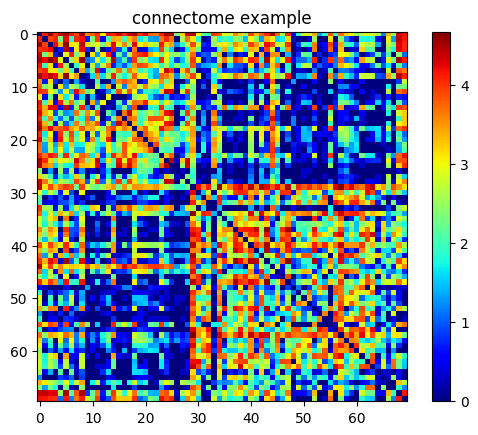

In [11]:
# plot a graph
import matplotlib.pyplot as plt
%matplotlib inline
i = 10
# convert to numpy
matrix = nx.to_numpy_array(graphs[i], nodelist=sorted(graphs[i].nodes())) #this is how you go to a matrix

plt.imshow(np.log10(matrix+1),cmap='jet')
plt.colorbar()
plt.title('connectome example')
plt.show()

# of graphs: 207
Adjacency array shape: (207, 70, 70)
SEX
2    108
1     99
Name: count, dtype: int64


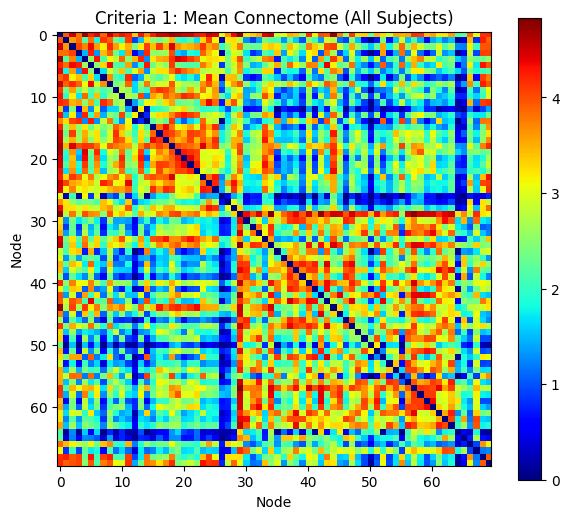

In [17]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Build aligned adjacency matrices for each and every subject
all_mats = []
for i in range(len(graphs)):
    G = graphs[i]
    mat = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
    all_mats.append(mat)

all_mats = np.array(all_mats)

print("# of graphs:", len(graphs))
print("Adjacency array shape:", all_mats.shape)
print(attributes['SEX'].value_counts(dropna=False))


# Criteria 1 (25 points) compute and visualize mean connectomes for all of the data
mean_connectome = np.mean(all_mats, axis=0)

plt.figure(figsize=(7, 6))
plt.imshow(np.log10(mean_connectome + 1), cmap='jet')
plt.colorbar()
plt.title('Criteria 1: Mean Connectome (All Subjects)')
plt.xlabel('Node')
plt.ylabel('Node')
plt.show()

Male count: 99
Female count: 108


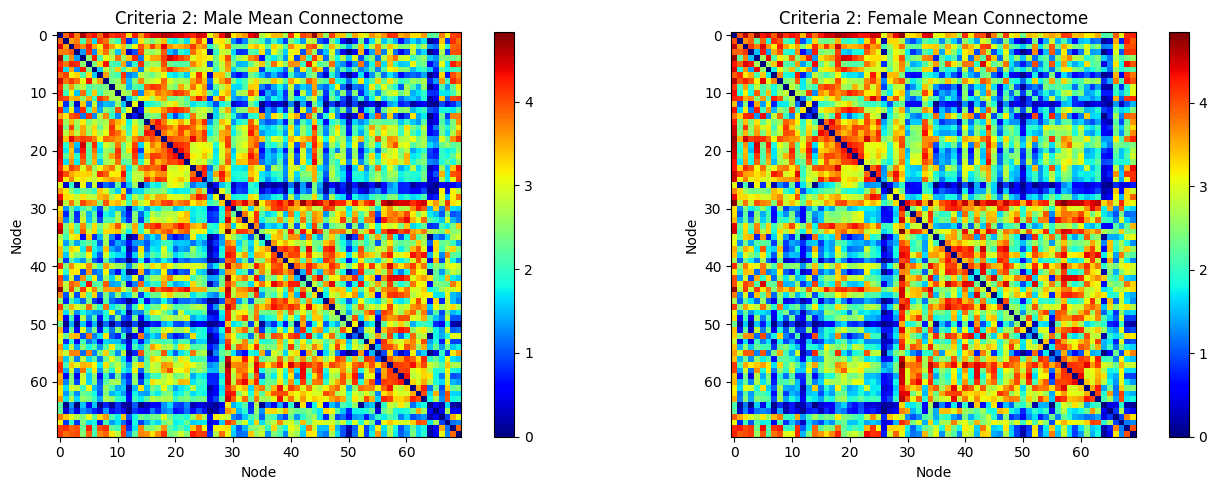

In [18]:
# Criteria 2 (25 points) compute and visualize class conditional connectomes (e.g., male and female subpopulations)
sex_series = attributes['SEX'].astype(str).str.strip().str.lower()

male_idx = sex_series.isin(['m', 'male', '1', '1.0'])
female_idx = sex_series.isin(['f', 'female', '0', '0.0', '2', '2.0'])

print("Male count:", male_idx.sum())
print("Female count:", female_idx.sum())

male_mean = np.mean(all_mats[male_idx.values], axis=0)
female_mean = np.mean(all_mats[female_idx.values], axis=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.log10(male_mean + 1), cmap='jet')
plt.colorbar()
plt.title('Criteria 2: Male Mean Connectome')
plt.xlabel('Node')
plt.ylabel('Node')

plt.subplot(1, 2, 2)
plt.imshow(np.log10(female_mean + 1), cmap='jet')
plt.colorbar()
plt.title('Criteria 2: Female Mean Connectome')
plt.xlabel('Node')
plt.ylabel('Node')

plt.tight_layout()
plt.show()

In [20]:
# Criteria 3 (30 points) compute 5 different features related to graphs
feature_rows = []

for i in range(len(graphs)):
    G = graphs[i]
    mat = all_mats[i]

    num_edges = G.number_of_edges()
    density = nx.density(G)

    deg_cent = nx.degree_centrality(G)
    mean_degree_centrality = np.mean(list(deg_cent.values()))

    avg_clustering = nx.average_clustering(G, weight='weight')

    node_strengths = np.sum(mat, axis=1)
    mean_strength = np.mean(node_strengths)

    feature_rows.append([
        num_edges,
        density,
        mean_degree_centrality,
        avg_clustering,
        mean_strength
    ])

X5 = pd.DataFrame(
    feature_rows,
    columns=[
        'num_edges',
        'density',
        'mean_degree_centrality',
        'avg_clustering',
        'mean_strength'
    ]
)

print(X5.head())
print(X5.describe())



   num_edges   density  mean_degree_centrality  avg_clustering  mean_strength
0       2152  0.891097                0.891097        0.015815  178959.000000
1       2091  0.865839                0.865839        0.018873  166874.828571
2       2202  0.911801                0.911801        0.014805  202841.200000
3       2185  0.904762                0.904762        0.018959  210767.857143
4       2176  0.901035                0.901035        0.018630  138145.142857
         num_edges     density  mean_degree_centrality  avg_clustering  \
count   207.000000  207.000000              207.000000      207.000000   
mean   2167.748792    0.897619                0.897619        0.015684   
std      86.639666    0.035876                0.035876        0.002085   
min    1902.000000    0.787578                0.787578        0.011139   
25%    2121.500000    0.878468                0.878468        0.014080   
50%    2174.000000    0.900207                0.900207        0.015630   
75%    2230.50

In [21]:
# Criteria 4 (20 points) interpret meaning of features, with some hypothesis connecting to neuroscience (words and/or code)
X5_with_label = X5.copy()
X5_with_label['SEX'] = attributes['SEX'].astype(str)

display(X5_with_label.groupby('SEX').mean())
display(X5_with_label.groupby('SEX').std())

,num_edges,density,mean_degree_centrality,avg_clustering,mean_strength
SEX,,,,,
1,2165.858586,0.896836,0.896836,0.015400,183123.246465
2,2169.481481,0.898336,0.898336,0.015943,211368.195503


,num_edges,density,mean_degree_centrality,avg_clustering,mean_strength
SEX,,,,,
1,70.743574,0.029293,0.029293,0.002089,49176.072549
2,99.305578,0.041120,0.041120,0.002057,48454.864614


In [15]:
#Develop features (examples)

X = []
for i in range(len(graphs)):
    featvec = []

    dc = nx.algorithms.degree_centrality(graphs[i])
    dcmean = np.mean(np.asarray(list(dc.values())))
    featvec.append(dcmean)

    dcall = np.asarray(list(dc.values()))
    for ii in dcall:
        featvec.append(ii)

    matrix = nx.to_numpy_array(graphs[i], nodelist=sorted(graphs[i].nodes())) #this is how you go to a matrix
    logmatrix = np.log10(np.sum(matrix,0) + 1)
    logmatrix = np.ravel(logmatrix)

    for ii in logmatrix:
        featvec.append(ii)

    xsum = np.asarray(np.sum(matrix))
    featvec.append(xsum)
    np.shape(featvec)
    X.append(featvec)


In [22]:
# Criteria 5 (30 points) build classifier and obtain classification score at 70\% or higher
# 80% should be very achievable

# separate training and test data and run classifier - you don't need to alter this cell

#X_train = X[0:100]
#Y_train = depvar[0:100]

#X_test = X[100:]
#Y_test = depvar[100:]

from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

#accuracy = []
#for ii in range(10): #performance will change over time
    #clf = svm.SVC(gamma='scale')
 #   clf = RandomForestClassifier(n_estimators=100)
 #   clf.fit(X_train, Y_train)
#    acc = (clf.predict(X_test) == Y_test)
#    accval = (float(np.sum(acc))/float(len(Y_test)))
#    accuracy.append(accval)
#    print('Accuracy:',accval)

#print('Overall Accuracy:',str(np.mean(accuracy)))


advanced_features = []

for i in range(len(graphs)):
    mat = all_mats[i]
    G = graphs[i]

    num_edges = G.number_of_edges()
    density = nx.density(G)
    deg_cent = nx.degree_centrality(G)
    mean_degree_centrality = np.mean(list(deg_cent.values()))
    avg_clustering = nx.average_clustering(G, weight='weight')
    node_strengths = np.sum(mat, axis=1)
    mean_strength = np.mean(node_strengths)

    # Use upper triangle of adjacency matrix so we don't duplicate symmetric values
    tri = mat[np.triu_indices_from(mat, k=1)]

    feat = np.concatenate([
        np.array([
            num_edges,
            density,
            mean_degree_centrality,
            avg_clustering,
            mean_strength
        ]),
        tri
    ])

    advanced_features.append(feat)

X_adv = np.array(advanced_features)
print("X_adv shape:", X_adv.shape)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train = X_adv[:100]
Y_train = depvar.iloc[:100]
X_test = X_adv[100:]
Y_test = depvar.iloc[100:]

accuracy = []

for ii in range(10):
    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=ii,
        max_features='sqrt'
    )
    clf.fit(X_train, Y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(Y_test, pred)
    accuracy.append(acc)
    print("Accuracy:", acc)

print("Overall Accuracy:", np.mean(accuracy))

X_adv shape: (207, 2420)
Accuracy: 0.7663551401869159
Accuracy: 0.7570093457943925
Accuracy: 0.7663551401869159
Accuracy: 0.7570093457943925
Accuracy: 0.7663551401869159
Accuracy: 0.7757009345794392
Accuracy: 0.7757009345794392
Accuracy: 0.7757009345794392
Accuracy: 0.7757009345794392
Accuracy: 0.7850467289719626
Overall Accuracy: 0.7700934579439253
